In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader as web
import scipy.optimize as opt
import csv
from scipy.optimize import minimize
from scipy.optimize import linprog
import math
from scipy.optimize import LinearConstraint

In [2]:
K = []
C_h = []
C_l = []
data = []
with open('Quotes.csv', mode='r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            data.append(row)
            K.append(float(row[0]))
            C_h.append(float(row[1]))
            C_l.append(float(row[2]))
#print(K)
#print(C_h)
#print(C_l)

In [3]:
S = 1271.87
N = len(K)
A = np.zeros((N-1+N-2+2,N))
b = np.zeros((N-1+N-2+2,1))
lb = np.zeros((N,1))
ub = np.zeros((N,1))

#A[0,0] = -1.0
for i in range(0,N-1):
    A[i,i] = -1.0
    A[i,i+1] = 1.0

for i in range(1,N-1):
    A[N-1+i-1,i-1] = -1.0/(K[i]-K[i-1])
    A[N-1+i-1,i] = 1.0/(K[i]-K[i-1]) + 1.0/(K[i+1]-K[i])
    A[N-1+i-1,i+1] = -1.0/(K[i+1]-K[i])

for i in range(0,N):
    lb[i] = max([0.0,S-K[i],C_l[i]])
    ub[i] = min([S,C_h[i]])

A[N-1+N-2,0] = 1.0/(K[1]-K[0]);
A[N-1+N-2,1] = -1.0/(K[1]-K[0]);
b[N-1+N-2,0] = 1.0;

A[N-1+N-2+1,N-2] = -1.0/(K[N-1]-K[N-2]);
A[N-1+N-2+1,N-1] = 1.0/(K[N-1]-K[N-2]);
b[N-1+N-2+1,0] = 0.0;

A = np.concatenate((A, np.identity(N), -np.identity(N)), axis=0)
b = np.concatenate((b, ub, -lb), axis=0)
b = b.T[0]

In [4]:
# Minimize c * x
c = np.zeros((1,N))
res = linprog(list(c), list(A), b)

#print("Optimal values:", res.x)
print("Optimal objective value:", -res.fun) # Negate back for maximization
print(min(b - A @ res.x))

Optimal objective value: -0.0
-7.105427357601002e-15


In [5]:
def objective(x):
    # Calculate the slack for each inequality
    slack = b - A @ x
    return -math.prod(slack)

# Initial guess for the center (e.g., origin)
x0 = res.x

# Perform the optimization
result = minimize(objective, x0, method='trust-constr', constraints=LinearConstraint(A, lb=-np.inf, ub=b))

if result.success:
    analytic_center = result.x
    print(f"Analytic Center: {analytic_center}")
else:
    print("Optimization failed:", result.message)

Analytic Center: [168.41333993 163.43212476 158.45978515 153.49349246 148.53187566
 143.57429861 138.62093449 133.67207098 128.72815462 123.7900251
 118.85893384 113.93676777 109.02682619 104.13153256  99.25290369
  94.3917554   89.54866101  84.72702743  79.93246093  75.26860042
  70.55134379  65.88444254  61.28134205  56.75053873  52.30394091
  47.95635716  43.71485787  39.57395751  35.524299    31.60569315
  27.9317954   24.48395044  21.2475926   18.25646378  15.49733597
  12.99405565  10.80110892   8.90284145   7.27003652   5.89351191
   4.79157789   3.91192005   3.28941796   2.57235837   2.09360721
   1.91310169   1.52496852   1.41942961   1.33926151   1.10014928]


In [6]:
print(min(b - A @ x0))
print(min(b - A @ result.x))
print(b - A @ result.x)
print(x0 - result.x)

-7.105427357601002e-15
0.0008079515028853734
[4.98121517e+00 4.97233961e+00 4.96629269e+00 4.96161680e+00
 4.95757704e+00 4.95336412e+00 4.94886351e+00 4.94391636e+00
 4.93812952e+00 4.93109125e+00 4.92216607e+00 4.90994159e+00
 4.89529363e+00 4.87862886e+00 4.86114829e+00 4.84309439e+00
 4.82163358e+00 4.79456650e+00 4.66386051e+00 4.71725663e+00
 4.66690125e+00 4.60310049e+00 4.53080332e+00 4.44659782e+00
 4.34758375e+00 4.24149928e+00 4.14090037e+00 4.04965851e+00
 3.91860585e+00 3.67389775e+00 3.44784496e+00 3.23635783e+00
 2.99112882e+00 2.75912781e+00 2.50328033e+00 2.19294673e+00
 1.89826747e+00 1.63280493e+00 1.37652461e+00 1.10193401e+00
 8.79657846e-01 6.22502091e-01 7.17059590e-01 4.78751158e-01
 1.80505520e-01 3.88133170e-01 1.05538911e-01 8.01681007e-02
 2.39112231e-01 1.77511199e-03 1.20938447e-03 9.35177570e-04
 8.07951503e-04 8.42584161e-04 9.00123043e-04 9.89428885e-04
 1.15736824e-03 1.40765388e-03 1.78503666e-03 2.44489664e-03
 2.92959088e-03 3.33295349e-03 3.4961142

In [7]:
call = result.x
print((call[0]-S)/K[0])
Kbar = 2000
print(-call[-1]/(Kbar-K[-1]))

-0.9995983875957215
-0.0017996880035724648


[168.41333993 163.43212476 158.45978515 153.49349246 148.53187566
 143.57429861 138.62093449 133.67207098 128.72815462 123.7900251
 118.85893384 113.93676777 109.02682619 104.13153256  99.25290369
  94.3917554   89.54866101  84.72702743  79.93246093  75.26860042
  70.55134379  65.88444254  61.28134205  56.75053873  52.30394091
  47.95635716  43.71485787  39.57395751  35.524299    31.60569315
  27.9317954   24.48395044  21.2475926   18.25646378  15.49733597
  12.99405565  10.80110892   8.90284145   7.27003652   5.89351191
   4.79157789   3.91192005   3.28941796   2.57235837   2.09360721
   1.91310169   1.52496852   1.41942961   1.33926151   1.10014928]


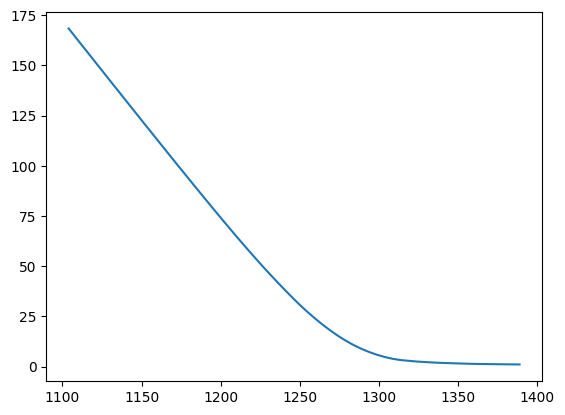

In [8]:
plt.plot(K,call)
print(call)

In [9]:
with open('ArbFree_calls_strikes.csv', 'w', newline='') as file3:
    writer = csv.writer(file3)
    writer.writerows([[call[i],K[i]] for i in range(len(call))])